In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import optax
import pysindy as ps
import matplotlib.pyplot as plt

In [4]:
%cd ..

c:\Users\mra15\OneDrive\MSc2026\Code\NO_SINDy_NO\4 - NO-SINDy\NeuralOperatorSINDy


In [2]:
%cd OneDrive\MSc2026\Code\NO_SINDy_NO\4 - NO-SINDy\NeuralOperatorSINDy

[WinError 3] The system cannot find the path specified: 'OneDrive\\MSc2026\\Code\\NO_SINDy_NO\\4 - NO-SINDy\\NeuralOperatorSINDy'
c:\Users\mra15\OneDrive\MSc2026\Code\NO_SINDy_NO\4 - NO-SINDy\NeuralOperatorSINDy\experiments\lorenz63


In [5]:
from pathlib import Path
from scipy.integrate import odeint

from src.training import (
    load_or_create_lorenz_data, sample_batch, SINDyAE, train, theta_jax,
    PoolingEncoder, LinearDecoder, DeepSetPooling,
)
from experiments.lorenz63.config import Config


In [6]:
cfg = Config()

# Data creation for lifted Lorenz63 System from Champion et al. (2019) "Data-driven discovery of coordinates and governing equations"
# cached under experiments/lorenz63 so repeated runs reuse the same data instead of regenerating it
lorenz63_dir = Path.cwd() / "experiments" / "lorenz63"
training_data = load_or_create_lorenz_data(
    lorenz63_dir / "training_data.npz", cfg.model.N_ICS, cfg.model.NOISE_STRENGTH,
    linear=cfg.model.LINEAR_OBS,
)
validation_data = load_or_create_lorenz_data(
    lorenz63_dir / "validation_data.npz", cfg.model.N_VAL, cfg.model.NOISE_STRENGTH,
    linear=cfg.model.LINEAR_OBS,
)


In [7]:
# Create a polynomial library for the SINDy model
_ps_lib = ps.PolynomialLibrary(degree=cfg.model.POLY_ORDER, include_bias=True)
_ps_lib.fit([np.zeros((2, cfg.model.LATENT_DIM))])
N_FEATURES = _ps_lib.n_output_features_
FEAT_NAMES = list(_ps_lib.get_feature_names_out([f'z{i}' for i in range(cfg.model.LATENT_DIM)]))
print(f'Library: {N_FEATURES} features  {FEAT_NAMES}')

model = SINDyAE(
    encoder=PoolingEncoder(
        latent_dim=cfg.model.LATENT_DIM,
        is_variational=False,
        pooling_fn=DeepSetPooling(mlp_dim=64, mlp_n_hidden_layers=2),
    ),
    decoder=LinearDecoder(
        out_dim=1,
        n_basis=cfg.model.LATENT_DIM,  # z's basis coefficients are the SINDy latent states themselves
        features=(64, 64, 64),
    ),
    n_features=N_FEATURES,
    latent_dim=cfg.model.LATENT_DIM,
    poly_order=cfg.model.POLY_ORDER,
)


Library: 20 features  ['1', 'z0', 'z1', 'z2', 'z0^2', 'z0 z1', 'z0 z2', 'z1^2', 'z1 z2', 'z2^2', 'z0^3', 'z0^2 z1', 'z0^2 z2', 'z0 z1^2', 'z0 z1 z2', 'z0 z2^2', 'z1^3', 'z1^2 z2', 'z1 z2^2', 'z2^3']


In [8]:
key = jax.random.PRNGKey(cfg.model.SEED)
key, init_key = jax.random.split(key)
rng = np.random.default_rng(cfg.model.SEED)
u0, udot0, x0 = sample_batch(training_data, cfg.training.BATCH_SIZE, rng)

mask = jnp.ones((N_FEATURES, cfg.model.LATENT_DIM))
params = model.init(init_key, u0, udot0, x0, mask)['params']

state, mask, loss_hist = train(cfg, model, params, mask, training_data, rng)


max|xi| at 1: 1.0010000467300415
max|xi| at 1000: 1.0653020143508911
max|xi| at 2000: 1.1088533401489258
prune @ 2000: active 60/60
prune @ 2500: active 60/60
max|xi| at 3000: 1.2057039737701416
prune @ 3000: active 60/60
prune @ 3500: active 60/60
max|xi| at 4000: 1.295059084892273
prune @ 4000: active 60/60
prune @ 4500: active 60/60
max|xi| at 5000: 1.3687770366668701
prune @ 5000: active 60/60
prune @ 5500: active 60/60
max|xi| at 6000: 1.4225006103515625
prune @ 6000: active 60/60
prune @ 6500: active 60/60
max|xi| at 7000: 1.44748055934906
prune @ 7000: active 59/60
prune @ 7500: active 59/60
max|xi| at 8000: 1.4433541297912598
prune @ 8000: active 59/60
prune @ 8500: active 59/60
max|xi| at 9000: 1.4188380241394043
prune @ 9000: active 59/60
prune @ 9500: active 57/60
max|xi| at 10000: 1.3801909685134888
prune @ 10000: active 57/60
prune @ 10500: active 56/60
max|xi| at 11000: 1.3810436725616455
prune @ 11000: active 54/60
prune @ 11500: active 53/60
max|xi| at 12000: 1.39230537

## Results

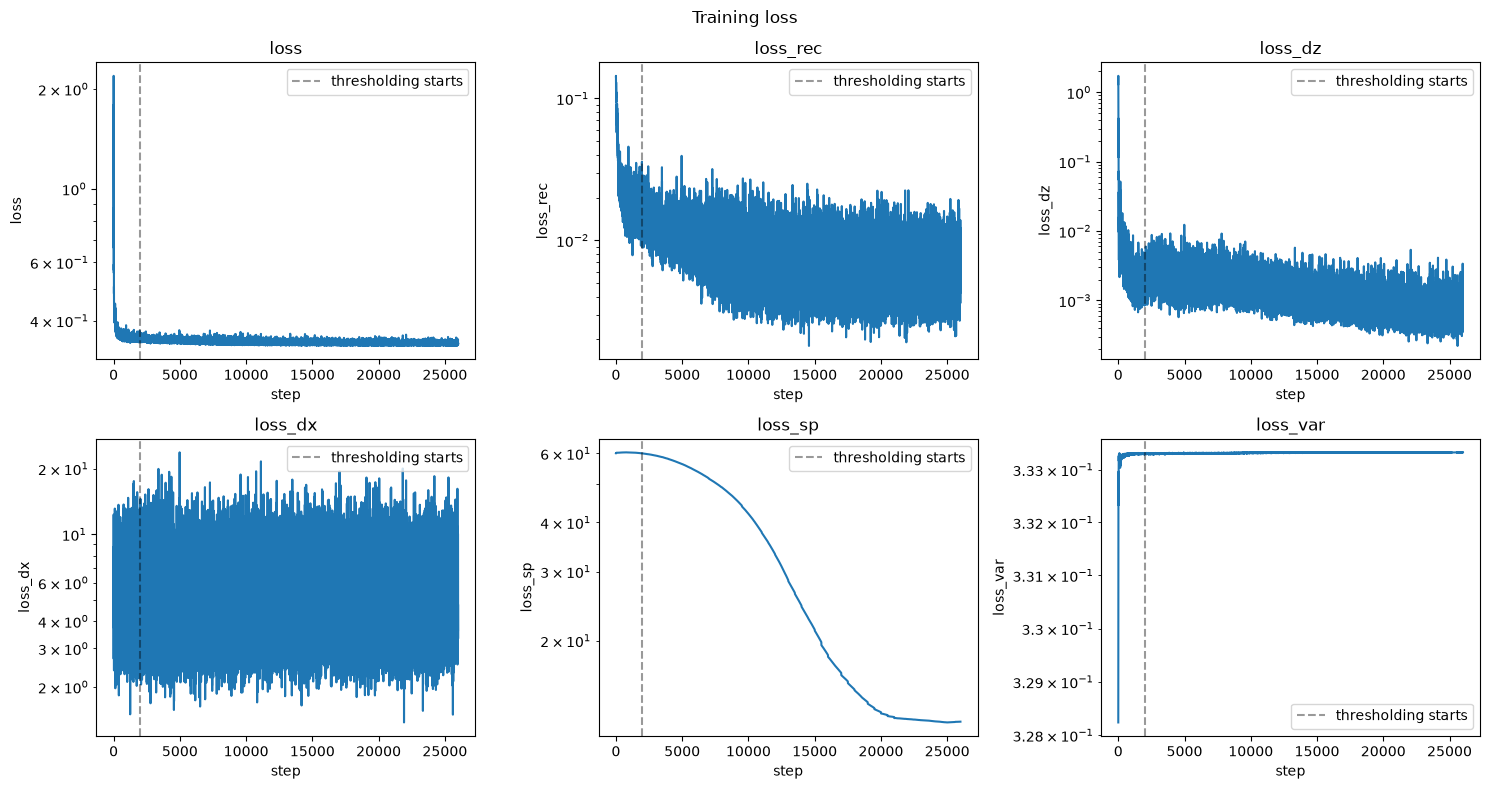

In [9]:
loss_arr = {k: np.array([h[k] for h in loss_hist]) for k in loss_hist[0]}

loss_names = ["loss", "loss_rec", "loss_dz", "loss_dx", "loss_sp", "loss_var"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, name in zip(axes.flat, loss_names):
    ax.plot(loss_arr[name])
    ax.axvline(cfg.loss.THRESH_START, color="k", linestyle="--", alpha=0.4, label="thresholding starts")
    ax.set_yscale("log")
    ax.set_xlabel("step")
    ax.set_ylabel(name)
    ax.set_title(name)
    ax.legend()
plt.suptitle("Training loss")
plt.tight_layout()
plt.show()


### Latent space

Encode the validation trajectories and look at the learned latent code: its time series,
its phase portrait, and how well it correlates with the true (normalised) Lorenz state.

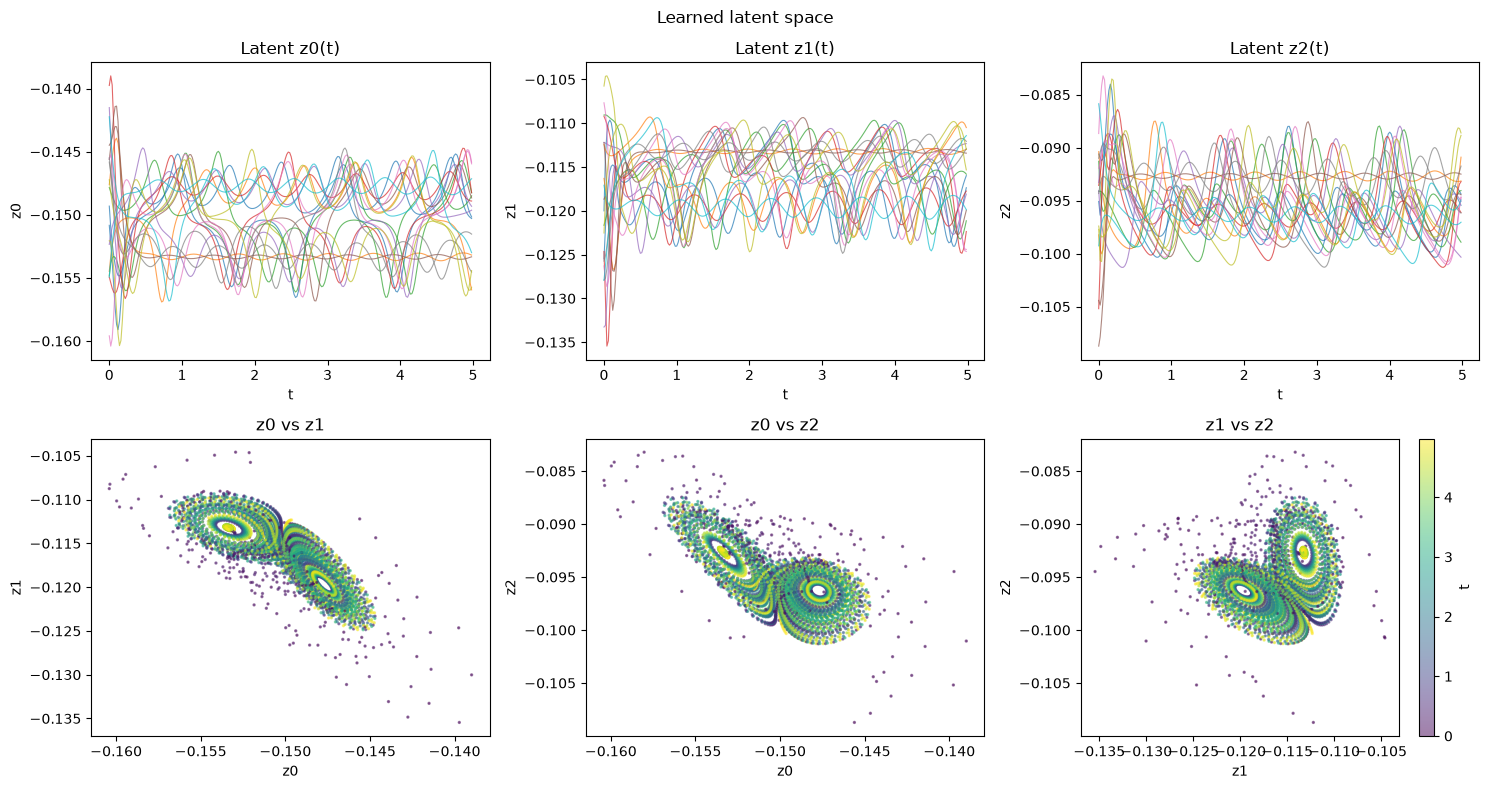

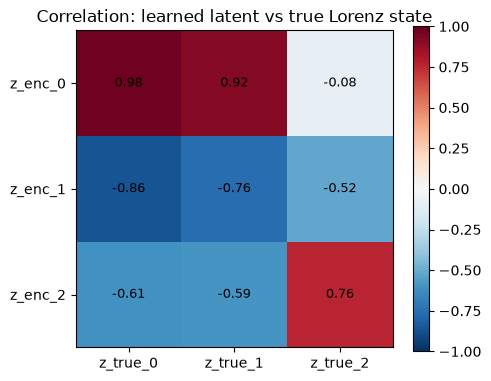

In [10]:
def encode_batch(u, x):
    return np.array(model.encoder.apply({'params': state.params['encoder']}, u, x))

n_steps = validation_data['t'].shape[0]
n_val = cfg.model.N_VAL
y_spatial = jnp.asarray(validation_data['y_spatial'])[None, :, None]

u_val_traj = validation_data['x'].reshape(n_val, n_steps, -1)[..., None]
z_true_traj = validation_data['z'].reshape(n_val, n_steps, cfg.model.LATENT_DIM)

z_enc_traj = np.zeros((n_val, n_steps, cfg.model.LATENT_DIM))
for i in range(n_val):
    x_b = jnp.broadcast_to(y_spatial, (n_steps, y_spatial.shape[1], 1))
    z_enc_traj[i] = encode_batch(jnp.asarray(u_val_traj[i]), x_b)

t_grid = validation_data['t']
colors = plt.cm.tab10(np.linspace(0, 1, n_val))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for d in range(cfg.model.LATENT_DIM):
    for i in range(n_val):
        axes[0, d].plot(t_grid, z_enc_traj[i, :, d], color=colors[i], lw=0.8, alpha=0.7)
    axes[0, d].set(xlabel='t', ylabel=f'z{d}', title=f'Latent z{d}(t)')
for k, (da, db) in enumerate([(0, 1), (0, 2), (1, 2)]):
    for i in range(n_val):
        sc = axes[1, k].scatter(z_enc_traj[i, :, da], z_enc_traj[i, :, db],
                                 c=t_grid, cmap='viridis', s=2, alpha=0.5)
    axes[1, k].set(xlabel=f'z{da}', ylabel=f'z{db}', title=f'z{da} vs z{db}')
plt.colorbar(sc, ax=axes[1, 2], label='t')
plt.suptitle('Learned latent space')
plt.tight_layout()
plt.show()

# correlation between the learned latent and the true (normalised) Lorenz state
z_enc_flat = z_enc_traj.reshape(-1, cfg.model.LATENT_DIM)
z_true_flat = z_true_traj.reshape(-1, cfg.model.LATENT_DIM)
corr = np.array([[np.corrcoef(z_enc_flat[:, zi], z_true_flat[:, ti])[0, 1]
                  for ti in range(cfg.model.LATENT_DIM)]
                 for zi in range(cfg.model.LATENT_DIM)])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set(xticks=range(cfg.model.LATENT_DIM), xticklabels=[f'z_true_{j}' for j in range(cfg.model.LATENT_DIM)],
       yticks=range(cfg.model.LATENT_DIM), yticklabels=[f'z_enc_{i}' for i in range(cfg.model.LATENT_DIM)],
       title='Correlation: learned latent vs true Lorenz state')
for zi in range(cfg.model.LATENT_DIM):
    for ti in range(cfg.model.LATENT_DIM):
        ax.text(ti, zi, f'{corr[zi, ti]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


In [11]:
np.set_printoptions(precision=3, suppress=True)
print("corr matrix (rows=z_enc_i, cols=z_true_j):")
print(corr)
print()
print("per z_enc row -> best matching z_true (argmax |corr|):", np.argmax(np.abs(corr), axis=1))
print("max |corr| per z_enc row:", np.abs(corr).max(axis=1))
print()
print("per z_true col -> best matching z_enc (argmax |corr|):", np.argmax(np.abs(corr), axis=0))
print("max |corr| per z_true col:", np.abs(corr).max(axis=0))


corr matrix (rows=z_enc_i, cols=z_true_j):
[[ 0.976  0.917 -0.081]
 [-0.86  -0.764 -0.517]
 [-0.608 -0.588  0.764]]

per z_enc row -> best matching z_true (argmax |corr|): [0 0 2]
max |corr| per z_enc row: [0.976 0.86  0.764]

per z_true col -> best matching z_enc (argmax |corr|): [0 0 2]
max |corr| per z_true col: [0.976 0.917 0.764]


### Forecasting

Integrate the learned SINDy ODE (theta(z) @ xi, using the trained + thresholded mask) forward
from an encoded latent state, and compare against the encoder's own trajectory over the
forecast horizon (not the raw ground-truth Lorenz state, since the encoder need not have
learned an axis-aligned copy of it).

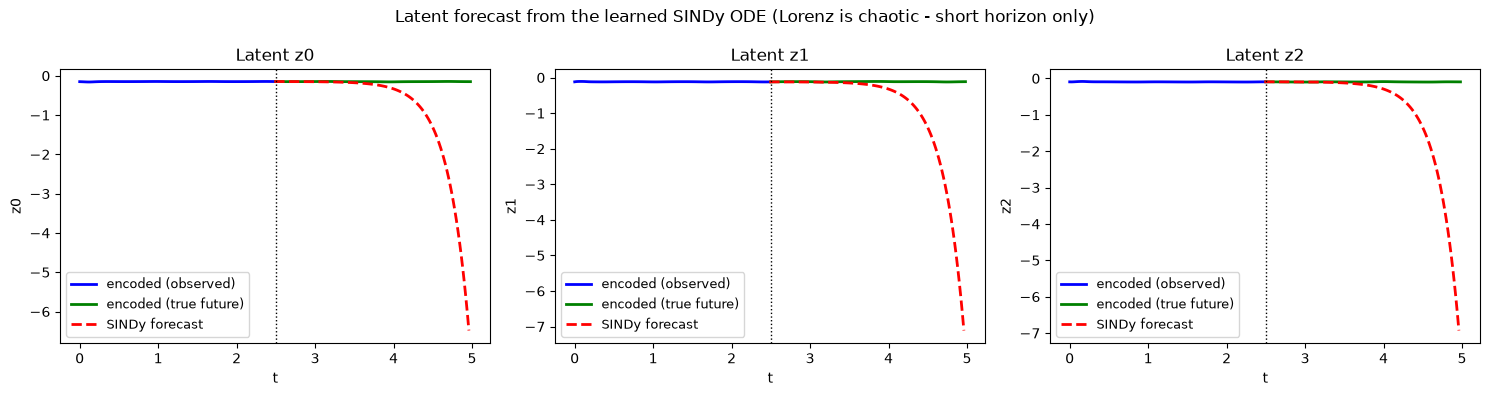

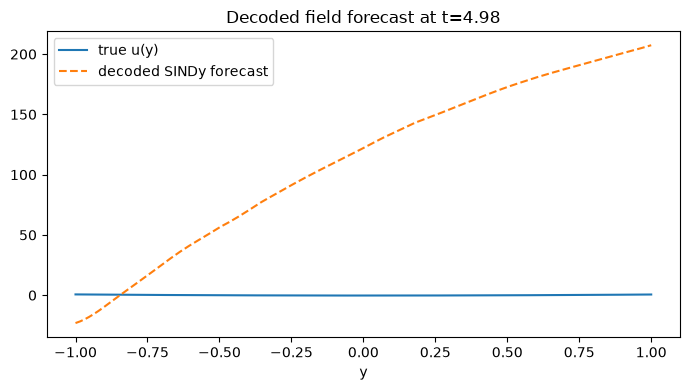

In [12]:
xi_final = np.array(state.params['xi']) * np.array(mask)

def sindy_rhs(z, t):
    theta = np.array(theta_jax(jnp.asarray(z)[None, :], cfg.model.POLY_ORDER, cfg.model.LATENT_DIM))[0]
    return theta @ xi_final

I_TRAJ = 0
T_OBS = n_steps // 2
T_FORE = n_steps - T_OBS

z0_fc = z_enc_traj[I_TRAJ, T_OBS - 1]
t_forecast = np.arange(T_FORE) * cfg.model.DT
z_forecast = odeint(sindy_rhs, z0_fc, t_forecast)

t_fc = t_grid[T_OBS - 1] + t_forecast

fig, axes = plt.subplots(1, cfg.model.LATENT_DIM, figsize=(5 * cfg.model.LATENT_DIM, 4))
for d, ax in enumerate(axes):
    ax.plot(t_grid[:T_OBS], z_enc_traj[I_TRAJ, :T_OBS, d], 'b-', lw=2, label='encoded (observed)')
    ax.plot(t_grid[T_OBS:], z_enc_traj[I_TRAJ, T_OBS:, d], 'g-', lw=2, label='encoded (true future)')
    ax.plot(t_fc, z_forecast[:, d], 'r--', lw=2, label='SINDy forecast')
    ax.axvline(t_grid[T_OBS], color='k', lw=1, ls=':')
    ax.set(xlabel='t', ylabel=f'z{d}', title=f'Latent z{d}')
    ax.legend(fontsize=9)
plt.suptitle('Latent forecast from the learned SINDy ODE (Lorenz is chaotic - short horizon only)')
plt.tight_layout()
plt.show()

# decode the forecast at the end of the horizon and compare to the true field there
u_true_last = validation_data['x'].reshape(n_val, n_steps, -1)[I_TRAJ, -1]
u_hat_last = np.array(model.decoder.apply(
    {'params': state.params['decoder']}, jnp.asarray(z_forecast[-1:]), y_spatial
))[0, :, 0]

plt.figure(figsize=(7, 4))
plt.plot(validation_data['y_spatial'], u_true_last, label='true u(y)')
plt.plot(validation_data['y_spatial'], u_hat_last, '--', label='decoded SINDy forecast')
plt.xlabel('y')
plt.legend()
plt.title(f'Decoded field forecast at t={t_grid[-1]:.2f}')
plt.tight_layout()
plt.show()


In [13]:
def format_equations(xi, feat_names, latent_dim, threshold=1e-3, precision=3):
      lines = []                                                                                                   
      for d in range(latent_dim):
          terms = [
              f"{coef:+.{precision}f} {name}"
              for coef, name in zip(xi[:, d], feat_names)
              if abs(coef) >= threshold
          ]
          rhs = " ".join(terms) if terms else "0"
          lines.append(f"dz{d}/dt = {rhs}")
      return "\n".join(lines)

print(format_equations(xi_final, FEAT_NAMES, cfg.model.LATENT_DIM))

dz0/dt = +0.424 1 +1.232 z0 +1.260 z1 +0.976 z2
dz1/dt = +0.468 1 +1.469 z0 +1.035 z1 +1.342 z2
dz2/dt = +0.467 1 +1.539 z0 +1.149 z1 +1.076 z2


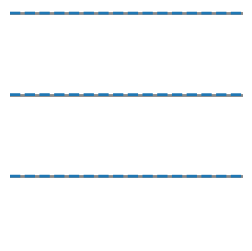

In [ ]:
z_sim = odeint(sindy_rhs, z_enc_traj[I_TRAJ, 0], t_grid)

plt.figure(figsize=(3, 3))
for i in range(cfg.model.LATENT_DIM):
    plt.subplot(cfg.model.LATENT_DIM, 1, i + 1)
    plt.plot(t_grid, z_enc_traj[I_TRAJ, :, i], color='#888888', linewidth=2)
    plt.plot(t_grid, z_sim[:, i], '--', linewidth=2)
    plt.xticks([])
    plt.yticks([])
    plt.xlim(t_grid[0], t_grid[-1])
    plt.axis('off')
plt.show()
